# Cargar y examinar los datos

In [1]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


#Importar base de datos
df = pd.read_csv('/datasets/users_behavior.csv')

In [2]:
print(df.head())
print(df.info())
print(df.describe())
print(df['is_ultra'].value_counts(normalize=True))

   calls  minutes  messages   mb_used  is_ultra
0   40.0   311.90      83.0  19915.42         0
1   85.0   516.75      56.0  22696.96         0
2   77.0   467.66      86.0  21060.45         0
3  106.0   745.53      81.0   8437.39         1
4   66.0   418.74       1.0  14502.75         0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB
None
             calls      minutes     messages       mb_used     is_ultra
count  3214.000000  3214.000000  3214.000000   3214.000000  3214.000000
mean     63.038892   438.208787    38.281269  17207.673836     0.306472
std      33.236368   234.569872    36.148326   7570.968246  

# Separar características y objetivo

In [3]:
features = df.drop(['is_ultra'], axis=1)
target = df['is_ultra']

# Dividir Data Set


Para garantizar una evaluación adecuada del modelo y evitar el sobreajuste, el conjunto de datos se dividió en tres subconjuntos:

60% para entrenamiento

20% para validación

20% para prueba

El conjunto de entrenamiento se utilizó para ajustar los parámetros de los modelos.

El conjunto de validación permitió comparar diferentes algoritmos y configuraciones de hiperparámetros, seleccionando el modelo con mejor desempeño.

Finalmente, el conjunto de prueba se empleó exclusivamente para evaluar la capacidad de generalización del modelo seleccionado sobre datos no vistos previamente.

Esta estrategia asegura una evaluación objetiva y evita que el modelo sea ajustado directamente sobre los datos de prueba.

In [4]:
# primero separar test (20%)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=54321
)

# luego separar validación del entrenamiento (25% del 80% = 20% total)
features_train, features_valid, target_train, target_valid = train_test_split(
    features_train, target_train, test_size=0.25, random_state=54321
)

# Prueba de diferentes modelos


Con el objetivo de identificar el modelo más adecuado para nuestro conjunto de datos, se evaluaron distintos algoritmos de clasificación. Esta etapa permitió comparar su desempeño y determinar cuál ofrece la mayor exactitud en la predicción del plan contratado por los usuarios.

Durante el proceso, se ajustaron diferentes hiperparámetros y se evaluó cada modelo utilizando el conjunto de validación. De esta manera, se garantizó una selección basada en métricas objetivas y se evitó el sobreajuste al conjunto de entrenamiento.

## Modelo 1: Decision Tree

In [5]:
best_tree = None
accuracy_tree = 0
best_depth = 0

for depth in range(1, 11):
    model = DecisionTreeClassifier(max_depth=depth, random_state=54321)
    model.fit(features_train, target_train)
    
    predictions_valid = model.predict(features_valid)
    accuracy = accuracy_score(target_valid, predictions_valid)
    
    if accuracy > accuracy_tree:
        best_tree = model
        accuracy_tree = accuracy
        best_depth = depth

print("Mejor profundidad de árbol:", best_depth)
print("Accuracy validación:", accuracy_tree)

Mejor profundidad de árbol: 5
Accuracy validación: 0.8180404354587869


## Modelo 2: Random Forest

In [6]:
best_forest = None
accuracy_forest = 0
best_est = 0
best_depth = 0

for est in range(10, 101, 10):
    for depth in range(1, 11):
        model = RandomForestClassifier(
            n_estimators=est,
            max_depth=depth,
            random_state=54321
        )
        
        model.fit(features_train, target_train)
        predictions_valid = model.predict(features_valid)
        accuracy = accuracy_score(target_valid, predictions_valid)
        
        if accuracy > accuracy_forest:
            best_forest = model
            accuracy_forest = accuracy
            best_est = est
            best_depth = depth

print("Mejor Random Forest:")
print("Estimadores:", best_est)
print("Profundidad máxima:", best_depth)
print("Accuracy validación:", accuracy_forest)

Mejor Random Forest:
Estimadores: 30
Profundidad máxima: 9
Accuracy validación: 0.8398133748055988


## Modelo 3: Regresión Logística

In [7]:
model_lr = LogisticRegression(random_state=54321, solver='liblinear')
model_lr.fit(features_train, target_train)

predictions_valid = model_lr.predict(features_valid)
accuracy_lr = accuracy_score(target_valid, predictions_valid)

print("Accuracy Regresión Logística:", accuracy_lr)

Accuracy Regresión Logística: 0.7325038880248833


# Comparativa entre los modelos seleccionados

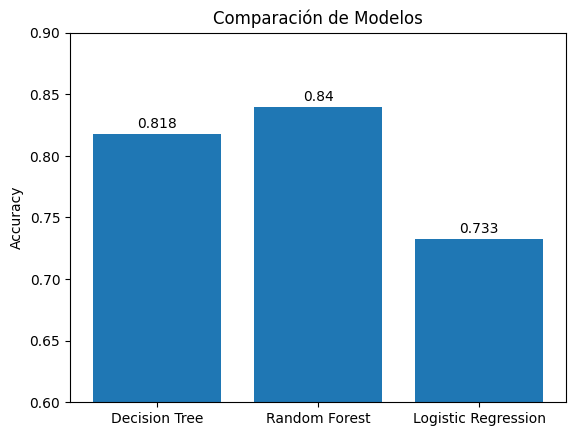

In [8]:
results = {
    'Decision Tree': accuracy_tree,
    'Random Forest': accuracy_forest,
    'Logistic Regression': accuracy_lr
}

plt.figure()

bars = plt.bar(results.keys(), results.values())

# Agregar valores encima de cada barra
for i, value in enumerate(results.values()):
    plt.text(i, value+0.005, round(value, 3), ha='center')

plt.ylabel('Accuracy')
plt.title('Comparación de Modelos')
plt.ylim(0.6, 0.9)

plt.show()

# Evaluación en el conjunto de prueba

In [9]:
final_model = best_forest

predictions_test = final_model.predict(features_test)
accuracy_test = accuracy_score(target_test, predictions_test)

print("Accuracy en test:", accuracy_test)

Accuracy en test: 0.7947122861586314


# Prueba de cordura (Sanity Check)

In [10]:
# predecir siempre la clase mayoritaria
majority_class = target_train.mode()[0]
dummy_predictions = [majority_class] * len(target_test)

dummy_accuracy = accuracy_score(target_test, dummy_predictions)

print("Accuracy modelo base:", dummy_accuracy)

Accuracy modelo base: 0.6640746500777605


# Conclusión

En este proyecto se desarrollaron y evaluaron tres modelos de clasificación: Árbol de Decisión, Random Forest y Regresión Logística, con el objetivo de predecir correctamente el plan contratado por los clientes.

Tras ajustar los hiperparámetros y comparar el desempeño en el conjunto de validación, el modelo de Random Forest obtuvo el mejor rendimiento, alcanzando una exactitud del 0.84 (83.9%), lo que indica una buena capacidad para capturar patrones en el comportamiento de los usuarios.

Al evaluar el modelo seleccionado en el conjunto de prueba, se obtuvo una exactitud del 0.79 (79.4%), superando el umbral mínimo requerido de 0.75 (75%). Esto confirma que el modelo generaliza adecuadamente a datos no vistos y no presenta un sobreajuste significativo.

Además, el modelo supera claramente al modelo base que predice siempre la clase mayoritaria, lo que demuestra que realmente está aprendiendo relaciones relevantes en los datos y aporta valor predictivo.

En conclusión, el modelo Random Forest es una solución adecuada para recomendar planes a los clientes de Megaline, ya que cumple con el criterio de calidad establecido y muestra un desempeño estable entre validación y prueba.